In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../data/yerba-mate-1970-2024.csv", encoding="latin-1")

In [3]:
produccion_anual = df.groupby("anio")["produccion_tm"].sum().reset_index()

produccion_anual

,anio,produccion_tm
0,1970,76788
1,1971,90460
2,1972,126714
3,1973,150963
4,1974,134529
5,1975,142308
6,1976,121135
7,1977,127167
8,1978,133436
9,1979,135200


In [4]:
X = produccion_anual[["anio"]]
y = produccion_anual["produccion_tm"]

In [5]:
modelo = LinearRegression()
modelo.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
anios_futuros = pd.DataFrame({
    "anio": [2025, 2026, 2027, 2028, 2029, 2030]
})

predicciones = modelo.predict(anios_futuros)

predicciones

array([ 961549.78585858,  979666.902886  ,  997784.01991341,
       1015901.13694083, 1034018.25396825, 1052135.37099567])

In [7]:
anios_futuros["produccion_predicha"] = predicciones

anios_futuros

,anio,produccion_predicha
0,2025,9.615498e+05
1,2026,9.796669e+05
2,2027,9.977840e+05
3,2028,1.015901e+06
4,2029,1.034018e+06
5,2030,1.052135e+06


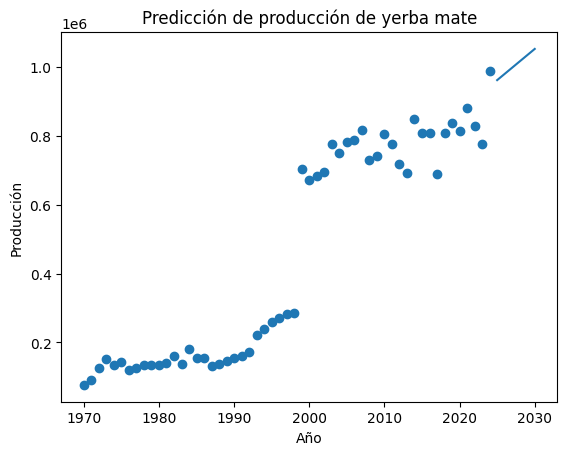

In [8]:
plt.scatter(X, y)
plt.plot(anios_futuros["anio"], predicciones)

plt.title("Predicción de producción de yerba mate")
plt.xlabel("Año")
plt.ylabel("Producción")

plt.show()

# Insight — Predicción de producción futura

El modelo de regresión lineal muestra una tendencia creciente en la producción de yerba mate.

Las predicciones indican que la producción continuará aumentando en los próximos años, reflejando una tendencia histórica positiva.

Esto sugiere que el sector yerbatero continuará expandiéndose en el futuro cercano.

In [9]:
from sklearn.metrics import r2_score

In [10]:
predicciones_historicas = modelo.predict(X)

In [11]:
r2 = r2_score(y, predicciones_historicas)

r2

0.847477700270544

In [12]:
print("R² score:", round(r2, 3))

R² score: 0.847


# Insight — Modelo predictivo confiable

El modelo de regresión lineal obtuvo un R² score de 0.847, lo que indica que explica el 84.7% de la variación en la producción de yerba mate.

Este valor confirma que existe una fuerte tendencia creciente en la producción a lo largo del tiempo.

El alto nivel de ajuste indica que el modelo es adecuado para realizar predicciones futuras y analizar la evolución del sector yerbatero argentino.

In [15]:
produccion_por_año = df.groupby("anio")["produccion_tm"].sum()

In [16]:
X = produccion_por_año.index.values.reshape(-1, 1)
y = produccion_por_año.values

In [17]:
print(X[:5])
print(y[:5])

[[1970]
 [1971]
 [1972]
 [1973]
 [1974]]
[ 76788  90460 126714 150963 134529]


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [19]:
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
import numpy as np

años_futuros = np.array([2025, 2026, 2027, 2028, 2029, 2030]).reshape(-1, 1)

In [21]:
predicciones = modelo.predict(años_futuros)

In [22]:
df_predicciones = pd.DataFrame({
    "Año": años_futuros.flatten(),
    "Producción predicha (toneladas)": predicciones.astype(int)
})

print(df_predicciones)

    Año  Producción predicha (toneladas)
0  2025                           963911
1  2026                           982033
2  2027                          1000154
3  2028                          1018275
4  2029                          1036397
5  2030                          1054518


In [23]:
df_predicciones.to_csv("predicciones_yerba_mate.csv", index=False)

In [24]:
plt.savefig("prediccion_yerba_mate.png")
plt.show()

<Figure size 640x480 with 0 Axes>

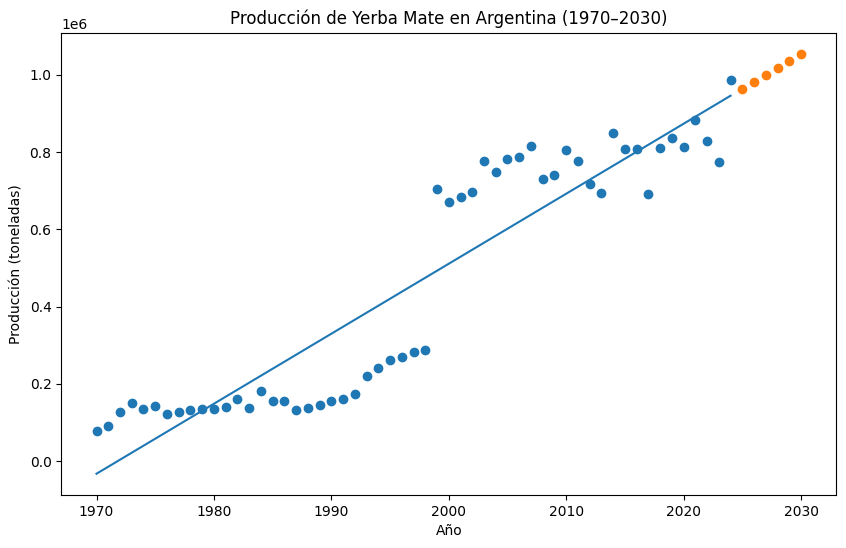

In [25]:
plt.figure(figsize=(10,6))

# Datos reales
plt.scatter(X, y)

# Línea del modelo
predicciones_modelo = modelo.predict(X)
plt.plot(X, predicciones_modelo)

# Predicciones futuras
plt.scatter(años_futuros, predicciones)

plt.title("Producción de Yerba Mate en Argentina (1970–2030)")
plt.xlabel("Año")
plt.ylabel("Producción (toneladas)")

plt.savefig("prediccion_yerba_mate.png")
plt.show()

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [27]:
produccion_por_año = df.groupby("anio")["produccion_tm"].sum()

X = produccion_por_año.index.values.reshape(-1, 1)
y = produccion_por_año.values

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
y_pred = modelo.predict(X)

In [31]:
años_futuros = np.array([2025, 2026, 2027, 2028, 2029, 2030]).reshape(-1, 1)
pred_futura = modelo.predict(años_futuros)

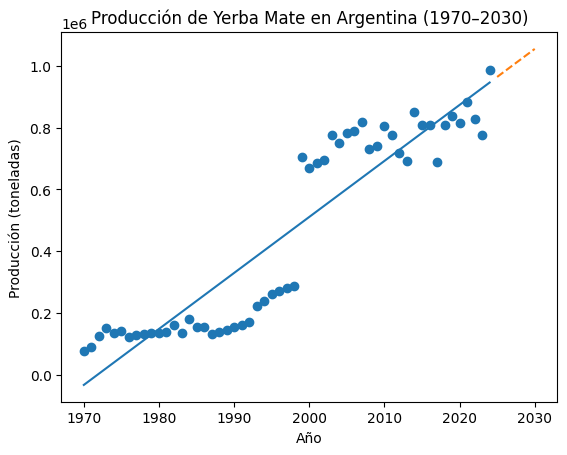

In [32]:
plt.figure()

# Datos reales
plt.scatter(X, y)

# Modelo (línea)
plt.plot(X, y_pred)

# Futuro (línea punteada)
plt.plot(años_futuros, pred_futura, linestyle="--")

plt.title("Producción de Yerba Mate en Argentina (1970–2030)")
plt.xlabel("Año")
plt.ylabel("Producción (toneladas)")

plt.show()

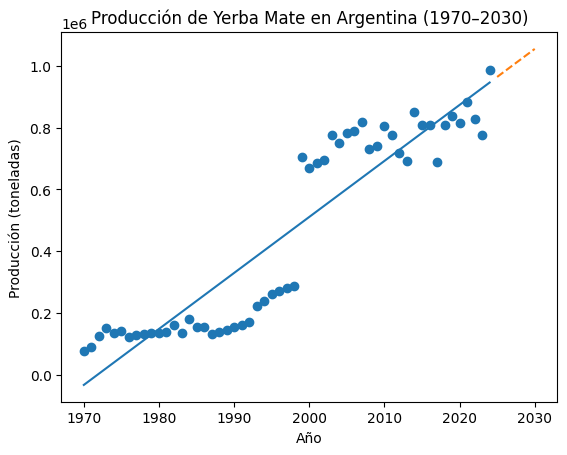

In [34]:
plt.figure()

plt.scatter(X, y)
plt.plot(X, y_pred)
plt.plot(años_futuros, pred_futura, linestyle="--")

plt.title("Producción de Yerba Mate en Argentina (1970–2030)")
plt.xlabel("Año")
plt.ylabel("Producción (toneladas)")

plt.savefig("../reports/produccion_2030.png")

plt.show()